In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
data_protein = pd.read_csv('resultado/04_annotados_protein.groups.tsv', sep='\t', index_col=0)

In [3]:
main_columns = ['CBB_01', 'CBB_02', 'CBB_03','rGlyP_07', 'rGlyP_08','rGlyP_09',]
num_columns = ['CBB_UP_01', 'CBB_UP_02', 'CBB_UP_03', 'rGlyP_UP_07', 'rGlyP_UP_08', 'rGlyP_UP_09']
all_columns = main_columns + num_columns
cepa_CBB = ['CBB_01', 'CBB_02', 'CBB_03']
cepa_rGlyP = ['rGlyP_07', 'rGlyP_08','rGlyP_09']
cepa_CBB_peptido = ['CBB_UP_01', 'CBB_UP_02', 'CBB_UP_03']
cepa_rGlyP_peptido = ['rGlyP_UP_07', 'rGlyP_UP_08', 'rGlyP_UP_09']

In [4]:
data_protein[main_columns]

,CBB_01,CBB_02,CBB_03,rGlyP_07,rGlyP_08,rGlyP_09
Entry,,,,,,
O07451,26.392931,26.320032,26.349343,20.835043,21.201639,19.946541
O30338,21.483608,21.568191,21.640735,21.467156,21.488334,21.483205
O87816,27.211578,27.108774,27.220774,27.499516,27.533413,27.568671
P14611,32.618989,32.412991,32.299652,32.993430,32.812984,32.921867
P14697,27.982094,28.089317,28.277010,28.806529,28.993055,29.002088
...,...,...,...,...,...,...
Q7WXU0,26.380829,26.527723,26.582587,24.817430,24.982458,24.917217
Q83WS0,20.024516,20.853302,19.333546,33.212505,33.180884,33.246544
Q8KLU8,22.928322,22.878103,22.630112,23.168801,23.044661,23.121074


In [5]:
from scipy import stats
import numpy as np

mean_cbb = data_protein[cepa_CBB].mean(axis=1)
mean_rglyp = data_protein[cepa_rGlyP].mean(axis=1)

data_protein['log2FC'] = mean_rglyp - mean_cbb

t_stat, p_val = stats.ttest_ind(
    data_protein[cepa_rGlyP], 
    data_protein[cepa_CBB], 
    axis=1, 
    nan_policy='propagate'
)

data_protein['p_value'] = p_val
data_protein['neg_log10_p'] = -np.log10(p_val)

In [6]:
from statsmodels.stats.multitest import multipletests

# Aplicamos corrección
rej, p_adj, _, _ = multipletests(data_protein['p_value'], method='fdr_bh')
data_protein['p_adj_fdr'] = p_adj

In [7]:
data_protein['neg_log10_p'] = -np.log10(p_adj)

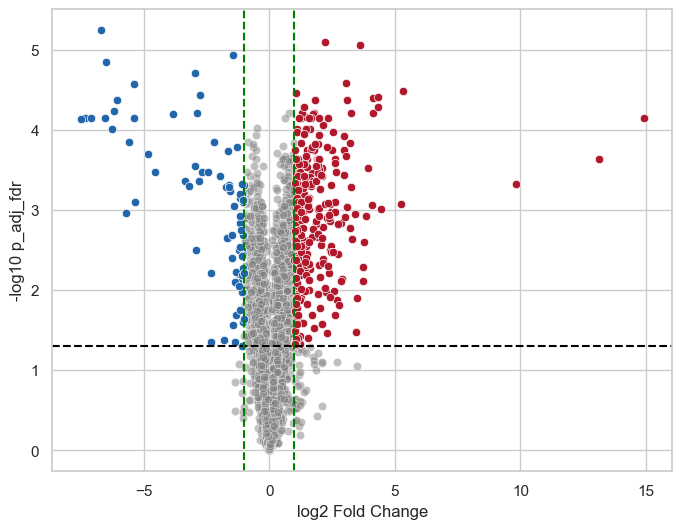

In [8]:
plt.figure(figsize=(8, 6))

df_sig = data_protein[(data_protein['p_adj_fdr'] < 0.05) & (abs(data_protein['log2FC']) > 1)]

df_sig_pos = df_sig[df_sig['log2FC']>1]
df_sig_neg = df_sig[df_sig['log2FC']<-1]

sns.scatterplot(data=data_protein, x='log2FC', y='neg_log10_p', color='grey', alpha=0.5)
sns.scatterplot(data=df_sig_neg, x='log2FC', y='neg_log10_p', color='#2166ac')
sns.scatterplot(data=df_sig_pos, x='log2FC', y='neg_log10_p', color='#b2182b')

plt.axhline(-np.log10(0.05), color='black', linestyle='--')
plt.axvline(1, color='green', linestyle='--')         
plt.axvline(-1, color='green', linestyle='--')             

plt.xlabel('log2 Fold Change')
plt.ylabel('-log10 p_adj_fdr')
plt.savefig('figuras/06-sample-two-tests.png', dpi=300)
plt.show()

In [9]:
df_sig_pos.to_csv('resultado/06_upregulate_protein.groups.tsv', sep='\t')
df_sig_neg.to_csv('resultado/06_downregulate_protein.groups.tsv', sep='\t')


In [10]:
df_sig_neg.columns

Index(['CBB_01', 'CBB_02', 'CBB_03', 'rGlyP_07', 'rGlyP_08', 'rGlyP_09',
       'CBB_UP_01', 'CBB_UP_02', 'CBB_UP_03', 'rGlyP_UP_07', 'rGlyP_UP_08',
       'rGlyP_UP_09', 'CBB_01_imputado', 'CBB_02_imputado', 'CBB_03_imputado',
       'rGlyP_07_imputado', 'rGlyP_08_imputado', 'rGlyP_09_imputado',
       'Entry Name', 'Protein names', 'Gene Names', 'Organism', 'Length',
       'Gene Ontology (biological process)',
       'Gene Ontology (cellular component)', 'Gene Ontology (GO)',
       'Gene Ontology (molecular function)', 'Gene Ontology IDs', 'KEGG',
       'log2FC', 'p_value', 'neg_log10_p', 'p_adj_fdr'],
      dtype='object')

In [11]:

df_sig['color'] = None
df_sig.loc[df_sig['log2FC'] > 1, 'color'] = 'red'
df_sig.loc[df_sig['log2FC'] < -1, 'color'] = 'blue'


data_protein['regulate'] = 'no_keep'
data_protein.loc[data_protein['log2FC'] > 1, 'regulate'] = 'upregulate'
data_protein.loc[data_protein['log2FC'] < -1, 'regulate'] = 'downregulate'

data_protein['color'] = 'gray'
data_protein.loc[data_protein['log2FC'] > 1, 'color'] = 'red'
data_protein.loc[data_protein['log2FC'] < -1, 'color'] = 'blue'

/var/folders/l8/h0dj8mwj1dn00s7s4ryzb8cw0000gn/T/ipykernel_24408/1593049555.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sig['color'] = None


In [12]:
data_protein.to_csv('resultado/06_regulate_protein.groups.tsv', sep='\t')

In [13]:
df_sig[['KEGG', 'color']].to_csv('resultado/06_kegg.txt', sep=' ', index=None, header=None)

In [14]:
df_sig[['KEGG', 'log2FC']].to_csv('resultado/06_kegg_continuo.txt', sep=' ', index=None, header=None)

In [15]:
data_protein

,CBB_01,CBB_02,CBB_03,rGlyP_07,rGlyP_08,rGlyP_09,CBB_UP_01,CBB_UP_02,CBB_UP_03,rGlyP_UP_07,...,Gene Ontology (GO),Gene Ontology (molecular function),Gene Ontology IDs,KEGG,log2FC,p_value,neg_log10_p,p_adj_fdr,regulate,color
Entry,,,,,,,,,,,,,,,,,,,,,
O07451,26.392931,26.320032,26.349343,20.835043,21.201639,19.946541,29,34,33,0,...,carboxyl- or carbamoyltransferase activity [GO...,carboxyl- or carbamoyltransferase activity [GO...,GO:0003725; GO:0008270; GO:0016743; GO:0016874...,reh:PHG096,-5.693028,0.000108,2.957351,0.001103,downregulate,blue
O30338,21.483608,21.568191,21.640735,21.467156,21.488334,21.483205,3,3,3,3,...,cytoplasm [GO:0005737]; nickel cation binding ...,nickel cation binding [GO:0016151]; unfolded p...,GO:0005737; GO:0006457; GO:0016151; GO:0019627...,reh:H16_A1085,-0.084613,0.138715,0.694974,0.201849,no_keep,gray
O87816,27.211578,27.108774,27.220774,27.499516,27.533413,27.568671,12,9,12,12,...,cytoplasm [GO:0005737]; sulfur carrier activit...,sulfur carrier activity [GO:0097163]; sulfurtr...,GO:0005737; GO:0006777; GO:0016783; GO:0097163,reh:H16_A0643,0.353492,0.001002,2.312738,0.004867,no_keep,gray
P14611,32.618989,32.412991,32.299652,32.993430,32.812984,32.921867,68,66,69,68,...,cytoplasm [GO:0005737]; acetyl-CoA C-acetyltra...,acetyl-CoA C-acetyltransferase activity [GO:00...,GO:0003985; GO:0005737; GO:0042619,reh:H16_A1438,0.465549,0.012220,1.516066,0.030474,no_keep,gray
P14697,27.982094,28.089317,28.277010,28.806529,28.993055,29.002088,40,41,41,43,...,cytoplasm [GO:0005737]; acetoacetyl-CoA reduct...,acetoacetyl-CoA reductase activity [GO:0018454],GO:0005737; GO:0018454; GO:0042619,reh:H16_A1439,0.817750,0.001585,2.173495,0.006707,no_keep,gray
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q7WXU0,26.380829,26.527723,26.582587,24.817430,24.982458,24.917217,8,7,8,7,...,ATP binding [GO:0005524]; phosphorelay sensor ...,ATP binding [GO:0005524]; phosphorelay sensor ...,GO:0000155; GO:0005524; GO:0006355,reh:PHG022,-1.591344,0.000032,3.292796,0.000510,downregulate,blue
Q83WS0,20.024516,20.853302,19.333546,33.212505,33.180884,33.246544,0,0,0,84,...,ATP binding [GO:0005524]; formate-tetrahydrofo...,ATP binding [GO:0005524]; formate-tetrahydrofo...,GO:0004329; GO:0005524; GO:0035999,mea:Mex_1p0329,13.142856,0.000007,3.635009,0.000232,upregulate,red
Q8KLU8,22.928322,22.878103,22.630112,23.168801,23.044661,23.121074,5,5,5,5,...,cytoplasm [GO:0005737]; [isocitrate dehydrogen...,[isocitrate dehydrogenase (NADP+)] kinase acti...,GO:0004674; GO:0004721; GO:0005524; GO:0005737...,reh:H16_A0168,0.299333,0.039046,1.130478,0.074050,no_keep,gray


In [16]:
#https://www.kegg.jp/kegg-bin/color_pathway_object